# Healthcare Hospital Operations Analysis

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv("Hospital.csv")

In [5]:
df

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
2,800002,2023-12-30,NaN,Chennai,Neurology,Inpatient,8.0,403505.37,Private,Recovered
3,800003,2023-08-02,NaN,Chennai,Neurology,Outpatient,22.0,19975.17,Private,Recovered
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,NaN,434580.60,Government,NaN
...,...,...,...,...,...,...,...,...,...,...
67995,821041,2024-05-31,Central,Pune,Oncology,Inpatient,21.0,463084.12,Self-Pay,Recovered
67996,844371,2023-11-07,NaN,Delhi,NaN,NaN,14.0,347293.28,Self-Pay,Critical
67997,835040,2023-10-30,NaN,NaN,Cardiology,Inpatient,6.0,367992.20,Self-Pay,Referred
67998,855047,2024-03-02,East,Chennai,Neurology,Inpatient,27.0,20610.72,Self-Pay,Recovered


In [6]:
df.shape

(68000, 10)

## Display_Head & Tail

In [7]:
First_Rows = df.head()
First_Rows

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
2,800002,2023-12-30,NaN,Chennai,Neurology,Inpatient,8.0,403505.37,Private,Recovered
3,800003,2023-08-02,NaN,Chennai,Neurology,Outpatient,22.0,19975.17,Private,Recovered
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,NaN,434580.60,Government,NaN


In [8]:
Last_Rows = df.tail()
Last_Rows

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
67995,821041,2024-05-31,Central,Pune,Oncology,Inpatient,21.0,463084.12,Self-Pay,Recovered
67996,844371,2023-11-07,NaN,Delhi,NaN,NaN,14.0,347293.28,Self-Pay,Critical
67997,835040,2023-10-30,NaN,NaN,Cardiology,Inpatient,6.0,367992.20,Self-Pay,Referred
67998,855047,2024-03-02,East,Chennai,Neurology,Inpatient,27.0,20610.72,Self-Pay,Recovered
67999,815102,2022-10-11,Central,Mumbai,NaN,Outpatient,17.0,73405.17,Self-Pay,Recovered


# Data Cleaning & EDA

In [9]:
Null_Vals = df.isnull().sum()
Null_Vals

Patient_ID                 0
Admission_Date             0
Hospital_Region        17082
City                    7519
Department              6862
Patient_Type            6805
Length_of_Stay_Days     2271
Treatment_Cost             0
Insurance_Type          6692
Discharge_Status        6725
dtype: int64

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df.describe()

,Patient_ID,Admission_Date,Length_of_Stay_Days,Treatment_Cost
count,65000.000000,65000,62825.000000,65000.000000
mean,832499.500000,2023-03-27 13:25:57.415384832,15.005905,249792.926702
min,800000.000000,2022-01-01 00:00:00,1.000000,520.760000
25%,816249.750000,2022-08-14 00:00:00,8.000000,123479.040000
50%,832499.500000,2023-03-27 00:00:00,15.000000,249187.560000
75%,848749.250000,2023-11-08 00:00:00,22.000000,375213.735000
max,864999.000000,2024-06-18 00:00:00,29.000000,499983.650000
std,18764.028086,NaN,8.369646,144779.001118


# Analysis

In [12]:
Mean = df.groupby("Department")["Treatment_Cost"].mean()
Mean

Department
Cardiology     248398.166266
General        249204.314511
Neurology      249627.873850
Oncology       251449.700907
Orthopedics    249280.717300
Pediatrics     250457.201630
Name: Treatment_Cost, dtype: float64

In [13]:
Mean2 = df.groupby("Patient_Type")["Length_of_Stay_Days"].mean()
Mean2

Patient_Type
Inpatient     15.001024
Outpatient    15.035673
Name: Length_of_Stay_Days, dtype: float64

# Visualizations

# Bar_Chart

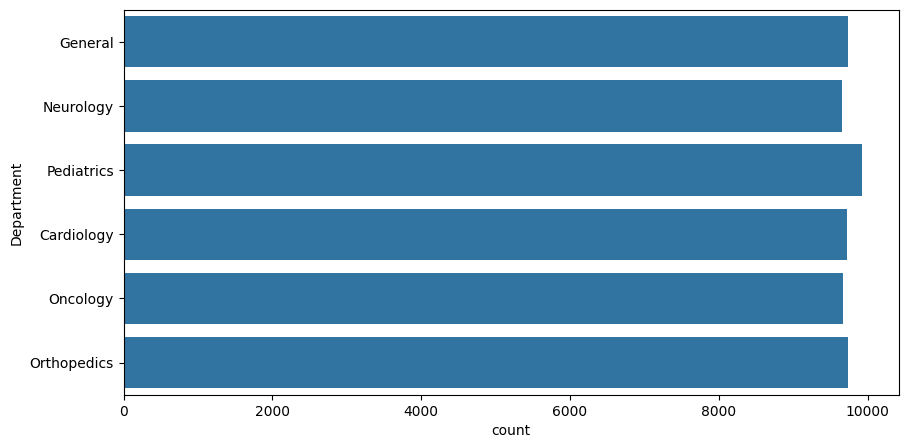

In [14]:
plt.figure(figsize = (10,5))
sns.countplot(y = "Department" , data = df)
plt.show()

# Line_Chart

C:\Users\bhatt\AppData\Local\Temp\ipykernel_4328\677476606.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Admission_Date').resample('M').size().plot(figsize=(10,5))


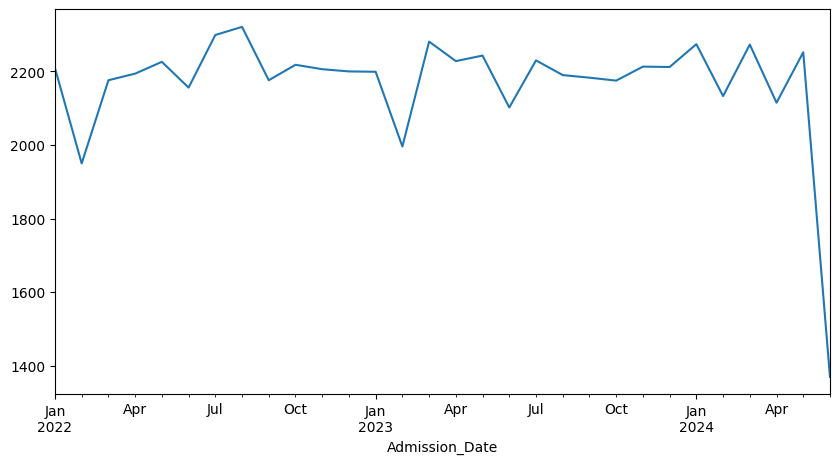

In [15]:
df.set_index('Admission_Date').resample('M').size().plot(figsize=(10,5))
plt.show()

# Histogram

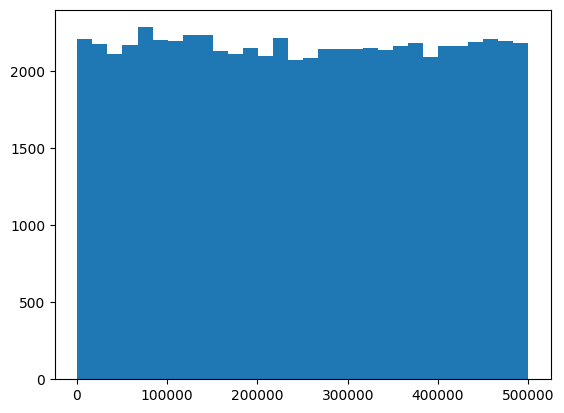

In [16]:
plt.hist(df["Treatment_Cost"], bins = 30)
plt.show()

# Pie_Plot

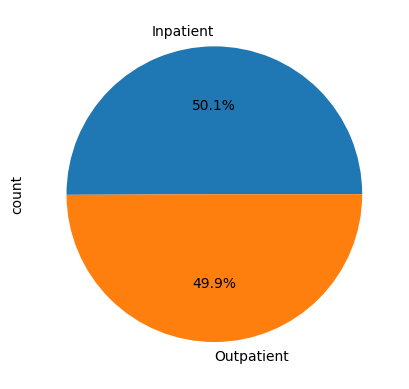

In [17]:
df["Patient_Type"].value_counts().plot.pie(autopct = "%1.1f%%")
plt.show()

# Scatter_Plot

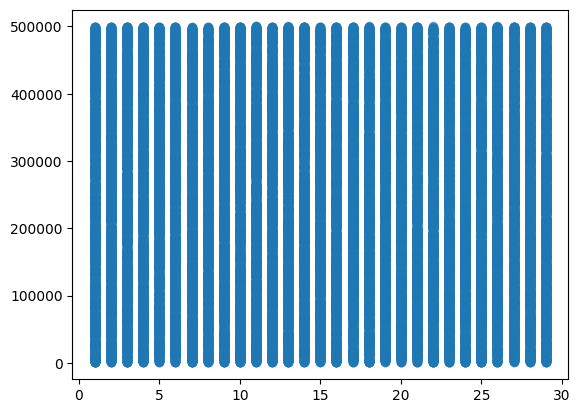

In [18]:
plt.scatter(df["Length_of_Stay_Days"], df["Treatment_Cost"], alpha = 0.5)
plt.show()